<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Dirac_Dynamics_V6b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet Dirac Dynamics — V6b

Builds an exact spectral positive-energy packet using \(u_+(k)\) for every Fourier mode, then repeats the V6 dynamical Dirac-like propagation test.

In [ ]:
# ============================================================
# CELL 1 — IMPORTS / OUTPUT SETUP
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json, zipfile

OUT = Path("ecsm_electron_like_dirac_dynamics_v6b_out")
OUT.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(OUT / name, dpi=180, bbox_inches="tight")
    plt.show()

print("Output folder:", OUT.resolve())


Output folder: /content/ecsm_electron_like_dirac_dynamics_v6b_out


In [ ]:
# ============================================================
# CELL 2 — PAULI / DIRAC MATRICES AND CLOSURE CHECKS
# ============================================================
I2 = np.eye(2, dtype=complex)
Z2 = np.zeros((2,2), dtype=complex)

sigma_x = np.array([[0,1],[1,0]], dtype=complex)
sigma_y = np.array([[0,-1j],[1j,0]], dtype=complex)
sigma_z = np.array([[1,0],[0,-1]], dtype=complex)

beta = np.block([[I2, Z2], [Z2, -I2]])
alpha1 = np.block([[Z2, sigma_x], [sigma_x, Z2]])
alpha2 = np.block([[Z2, sigma_y], [sigma_y, Z2]])
alpha3 = np.block([[Z2, sigma_z], [sigma_z, Z2]])

gamma0 = beta
gamma1 = beta @ alpha1
gamma2 = beta @ alpha2
gamma3 = beta @ alpha3
gammas = [gamma0, gamma1, gamma2, gamma3]
eta = np.diag([1,-1,-1,-1])
I4 = np.eye(4, dtype=complex)

cliff_rows = []
for mu in range(4):
    for nu in range(4):
        anti = gammas[mu] @ gammas[nu] + gammas[nu] @ gammas[mu]
        target = 2 * eta[mu,nu] * I4
        err = anti - target
        cliff_rows.append({
            "mu": mu, "nu": nu, "eta_munu": eta[mu,nu],
            "closure_error_fro": np.linalg.norm(err),
            "closure_error_max_abs": np.max(np.abs(err))
        })

cliff_df = pd.DataFrame(cliff_rows)
cliff_df.to_csv(OUT/"clifford_closure_tests_v6b.csv", index=False)

alpha_tests = [
    ("alpha_1^2=I", alpha1@alpha1 - I4),
    ("{alpha_1,beta}=0", alpha1@beta + beta@alpha1),
    ("alpha_2^2=I", alpha2@alpha2 - I4),
    ("{alpha_2,beta}=0", alpha2@beta + beta@alpha2),
    ("alpha_3^2=I", alpha3@alpha3 - I4),
    ("{alpha_3,beta}=0", alpha3@beta + beta@alpha3),
    ("{alpha_1,alpha_2}=0", alpha1@alpha2 + alpha2@alpha1),
    ("{alpha_1,alpha_3}=0", alpha1@alpha3 + alpha3@alpha1),
    ("{alpha_2,alpha_3}=0", alpha2@alpha3 + alpha3@alpha2),
    ("beta^2=I", beta@beta - I4),
]
alpha_df = pd.DataFrame([{"test": n, "error": float(np.max(np.abs(m)))} for n, m in alpha_tests])
alpha_df.to_csv(OUT/"alpha_beta_algebra_tests_v6b.csv", index=False)

print("Max Clifford closure error:", cliff_df["closure_error_max_abs"].max())
print("Max alpha/beta error:", alpha_df["error"].max())
display(cliff_df.head())
display(alpha_df)


Max Clifford closure error: 0.0
Max alpha/beta error: 0.0


,mu,nu,eta_munu,closure_error_fro,closure_error_max_abs
0,0,0,1,0.0,0.0
1,0,1,0,0.0,0.0
2,0,2,0,0.0,0.0
3,0,3,0,0.0,0.0
4,1,0,0,0.0,0.0


,test,error
0,alpha_1^2=I,0.0
1,"{alpha_1,beta}=0",0.0
2,alpha_2^2=I,0.0
3,"{alpha_2,beta}=0",0.0
4,alpha_3^2=I,0.0
5,"{alpha_3,beta}=0",0.0
6,"{alpha_1,alpha_2}=0",0.0
7,"{alpha_1,alpha_3}=0",0.0
8,"{alpha_2,alpha_3}=0",0.0
9,beta^2=I,0.0


In [ ]:
# ============================================================
# CELL 3 — FIXED V3b/V4b/V5 ELECTRON-LIKE PACKET SCAFFOLD
# ============================================================
packet = {
    "N_plus": 0.0009716378827065886,
    "N_zero": 1.000146008084612,
    "N_minus": 2.998882354032682,
    "q_eff": -0.9993035720499918,
    "R_rms": 5.236462555204353,
    "count_total": 4.0,
    "source": "V5 fixed V3b/V4b-like packet"
}
pd.DataFrame([packet]).to_csv(OUT/"fixed_packet_summary_v6b.csv", index=False)
print(json.dumps(packet, indent=2))


{
  "N_plus": 0.0009716378827065886,
  "N_zero": 1.000146008084612,
  "N_minus": 2.998882354032682,
  "q_eff": -0.9993035720499918,
  "R_rms": 5.236462555204353,
  "count_total": 4.0,
  "source": "V5 fixed V3b/V4b-like packet"
}


Initial norm: 1.0
Initial positive branch weight: 0.9999999999999989
Initial negative branch leakage: 1.5848525955670747e-33
Total branch weight: 0.9999999999999989


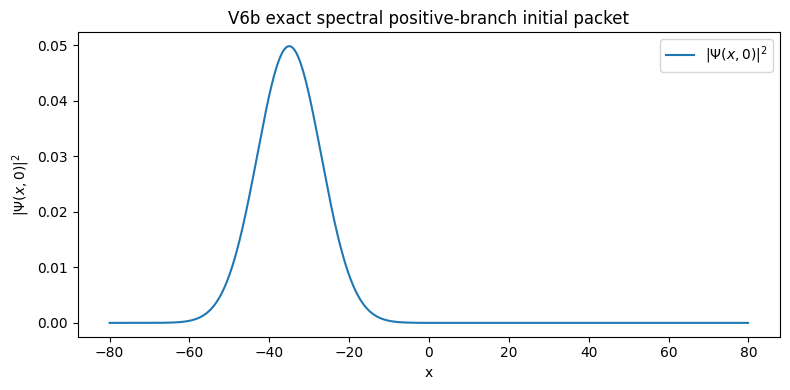

In [ ]:
# ============================================================
# CELL 4 — SPECTRAL GRID AND EXACT POSITIVE-BRANCH INITIAL PACKET
# ============================================================
plt.close("all")

N = 2048
L = 160.0
dx = L / N
x = (np.arange(N) - N//2) * dx
k = 2*np.pi*np.fft.fftfreq(N, d=dx)

x0 = -35.0
sigma_x = 8.0
k0 = 1.0
m_lock = 0.225463435330576

scalar_x = np.exp(-(x-x0)**2/(4*sigma_x**2)) * np.exp(1j*k0*x)
scalar_x = scalar_x / np.sqrt(np.sum(np.abs(scalar_x)**2)*dx)
scalar_k = np.fft.fft(scalar_x)

def Hk(kval, m=m_lock, chi=1.0):
    return np.sqrt(chi)*alpha1*kval + beta*m

def positive_spinor(kval, m=m_lock, chi=1.0):
    vals, vecs = np.linalg.eigh(Hk(kval, m=m, chi=chi))
    v = vecs[:, np.argmax(vals)]
    return v / np.linalg.norm(v)

def negative_spinor(kval, m=m_lock, chi=1.0):
    vals, vecs = np.linalg.eigh(Hk(kval, m=m, chi=chi))
    v = vecs[:, np.argmin(vals)]
    return v / np.linalg.norm(v)

# V6b improvement: use exact u_+(k) for every k-mode.
psi0_k = np.zeros((N,4), dtype=complex)
for i, kval in enumerate(k):
    psi0_k[i,:] = scalar_k[i] * positive_spinor(kval, chi=1.0)

psi0 = np.fft.ifft(psi0_k, axis=0)

def norm_psi(psi):
    return float(np.sum(np.sum(np.abs(psi)**2, axis=1))*dx)

psi0 = psi0 / np.sqrt(norm_psi(psi0))

def project_branch_weights(psi, chi=1.0):
    psik = np.fft.fft(psi, axis=0)
    wp = 0.0
    wn = 0.0
    for i, kval in enumerate(k):
        up = positive_spinor(kval, chi=chi)
        un = negative_spinor(kval, chi=chi)
        wp += abs(np.vdot(up, psik[i]))**2
        wn += abs(np.vdot(un, psik[i]))**2
    wp *= dx/N
    wn *= dx/N
    return float(np.real(wp)), float(np.real(wn))

wp0, wn0 = project_branch_weights(psi0, chi=1.0)
rho0 = np.sum(np.abs(psi0)**2, axis=1).real
pd.DataFrame({"x": x, "rho0": rho0}).to_csv(OUT/"initial_packet_density_v6b.csv", index=False)

print("Initial norm:", norm_psi(psi0))
print("Initial positive branch weight:", wp0)
print("Initial negative branch leakage:", wn0)
print("Total branch weight:", wp0+wn0)

plt.figure(figsize=(8,4))
plt.plot(x, rho0, label=r"$|\Psi(x,0)|^2$")
plt.xlabel("x")
plt.ylabel(r"$|\Psi(x,0)|^2$")
plt.title("V6b exact spectral positive-branch initial packet")
plt.legend()
savefig("fig_v6b_initial_packet_density.png")


In [ ]:
# ============================================================
# CELL 5 — EXACT SPECTRAL DIRAC PROPAGATOR
# ============================================================

def evolve_exact(psi, t, chi=1.0):
    psik = np.fft.fft(psi, axis=0)
    outk = np.zeros_like(psik)

    for i, kval in enumerate(k):
        H = Hk(kval, chi=chi)
        vals, vecs = np.linalg.eigh(H)

        coeff = vecs.conj().T @ psik[i]
        outk[i] = vecs @ (np.exp(-1j * vals * t) * coeff)

    return np.fft.ifft(outk, axis=0)


def expectation_x(psi):
    rho = np.sum(np.abs(psi)**2, axis=1).real
    norm = np.sum(rho) * dx
    return float(np.sum(x * rho) * dx / norm)


def width_x(psi):
    rho = np.sum(np.abs(psi)**2, axis=1).real
    norm = np.sum(rho) * dx
    xm = np.sum(x * rho) * dx / norm
    return float(np.sqrt(np.sum((x - xm)**2 * rho) * dx / norm))


def energy_expectation(psi, chi=1.0):
    psik = np.fft.fft(psi, axis=0)
    E = 0.0 + 0.0j

    for i, kval in enumerate(k):
        E += np.vdot(psik[i], Hk(kval, chi=chi) @ psik[i])

    E *= dx / N
    return float(np.real(E))


def project_branch_weights(psi, chi=1.0):
    """
    Complete positive/negative branch projection for a 4-component Dirac packet.

    The Dirac Hamiltonian has two positive-energy eigenvectors and two
    negative-energy eigenvectors at each k. We must sum over the full
    positive and negative eigenspaces.

    This fixes the false branch-weight loss seen in the chi scan.
    """

    psik = np.fft.fft(psi, axis=0)

    pos_weight_k = 0.0
    neg_weight_k = 0.0

    for i, kval in enumerate(k):
        H = Hk(kval, chi=chi)
        vals, vecs = np.linalg.eigh(H)

        psi_k = psik[i, :]

        for j, E in enumerate(vals):
            uj = vecs[:, j]
            amp = np.vdot(uj, psi_k)
            weight = abs(amp)**2

            if E >= 0:
                pos_weight_k += weight
            else:
                neg_weight_k += weight

    # Parseval factor for numpy FFT convention:
    # sum_x |psi|^2 dx = dx/N * sum_k |psi_k|^2
    wp = float((dx / N) * pos_weight_k)
    wn = float((dx / N) * neg_weight_k)

    return wp, wn


# Quick sanity check
for tt in [0, 1, 5]:
    psit = evolve_exact(psi0, tt, chi=1.0)
    print(
        tt,
        norm_psi(psit),
        expectation_x(psit),
        width_x(psit),
        project_branch_weights(psit, chi=1.0)
    )

0 1.0000000000000002 -34.99999933507956 8.000745152329351 (0.9999999999999988, 1.0923475422694743e-31)
1 1.0 -34.02475426473813 8.000745444501515 (0.9999999999999989, 8.838824319093795e-32)
5 1.0 -30.12377375377039 8.000759138251738 (0.9999999999999989, 1.0917611704193533e-31)


  t  norm     x_mean  x_width   energy  positive_branch_weight  negative_branch_weight  branch_leakage_negative  total_branch_weight   norm_error  branch_weight_error
0.0   1.0 -34.999999 8.000745 1.025195                     1.0            1.092348e-31             1.092348e-31                  1.0 2.220446e-16         1.221245e-15
0.5   1.0 -34.512377 8.000745 1.025195                     1.0            9.020784e-32             9.020784e-32                  1.0 2.220446e-16         1.221245e-15
1.0   1.0 -34.024754 8.000745 1.025195                     1.0            8.838824e-32             8.838824e-32                  1.0 0.000000e+00         1.110223e-15
1.5   1.0 -33.537132 8.000746 1.025195                     1.0            9.694939e-32             9.694939e-32                  1.0 1.110223e-16         8.881784e-16
2.0   1.0 -33.049509 8.000747 1.025195                     1.0            9.699800e-32             9.699800e-32                  1.0 3.330669e-16         1.332268e-1

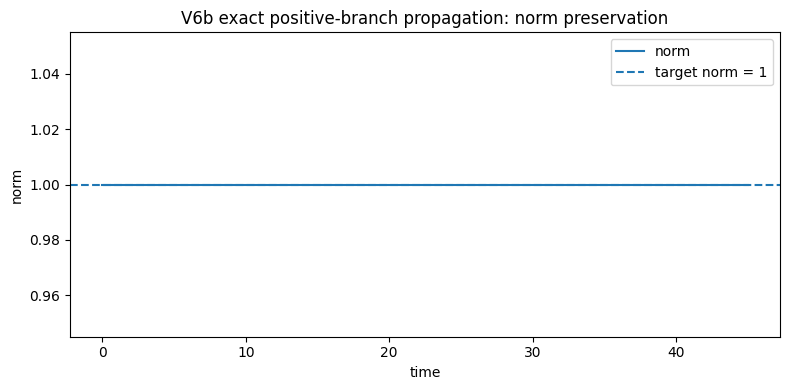

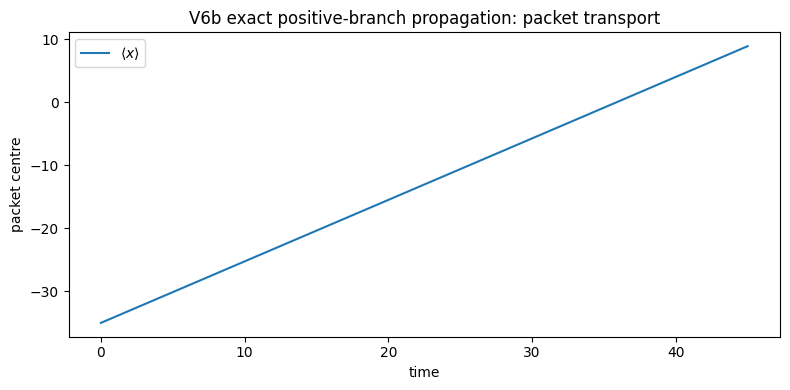

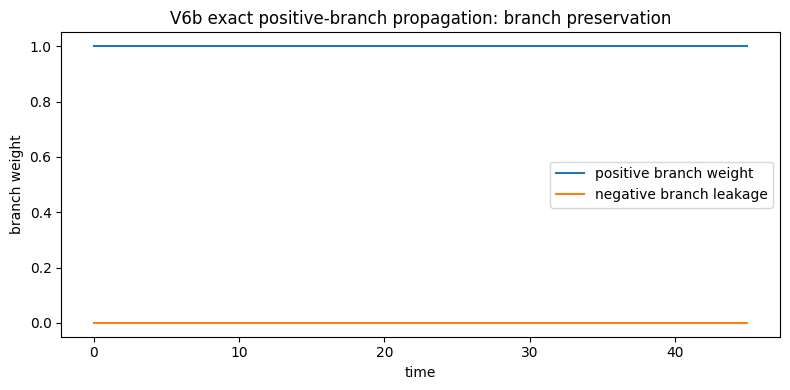

In [ ]:
# ============================================================
# CELL 6 — COHERENT DIRAC-LIKE PROPAGATION TEST
# ============================================================
plt.close("all")

times = np.linspace(0, 45, 91)
rows = []

for tt in times:
    psit = evolve_exact(psi0, tt, chi=1.0)
    wp, wn = project_branch_weights(psit, chi=1.0)
    rows.append({
        "t": tt,
        "norm": norm_psi(psit),
        "x_mean": expectation_x(psit),
        "x_width": width_x(psit),
        "energy": energy_expectation(psit, chi=1.0),
        "positive_branch_weight": wp,
        "negative_branch_weight": wn,
        "branch_leakage_negative": wn,
        "total_branch_weight": wp + wn
    })

dyn = pd.DataFrame(rows)
dyn["norm_error"] = np.abs(dyn["norm"] - 1.0)
dyn["branch_weight_error"] = np.abs(dyn["total_branch_weight"] - 1.0)
dyn.to_csv(OUT/"dirac_dynamics_history_v6b.csv", index=False)

print(dyn.head().to_string(index=False))
print("\\nMax norm error:", dyn["norm_error"].max())
print("Max branch weight error:", dyn["branch_weight_error"].max())
print("Max negative-branch leakage:", dyn["branch_leakage_negative"].max())
print("Negative leakage growth:", np.max(np.abs(dyn["branch_leakage_negative"] - dyn["branch_leakage_negative"].iloc[0])))

plt.figure(figsize=(8,4))
plt.plot(dyn["t"], dyn["norm"], label="norm")
plt.axhline(1.0, linestyle="--", label="target norm = 1")
plt.xlabel("time")
plt.ylabel("norm")
plt.title("V6b exact positive-branch propagation: norm preservation")
plt.legend()
savefig("fig_v6b_norm_preservation.png")

plt.figure(figsize=(8,4))
plt.plot(dyn["t"], dyn["x_mean"], label=r"$\langle x\rangle$")
plt.xlabel("time")
plt.ylabel("packet centre")
plt.title("V6b exact positive-branch propagation: packet transport")
plt.legend()
savefig("fig_v6b_packet_transport.png")

plt.figure(figsize=(8,4))
plt.plot(dyn["t"], dyn["positive_branch_weight"], label="positive branch weight")
plt.plot(dyn["t"], dyn["negative_branch_weight"], label="negative branch leakage")
plt.xlabel("time")
plt.ylabel("branch weight")
plt.title("V6b exact positive-branch propagation: branch preservation")
plt.legend()
savefig("fig_v6b_branch_preservation.png")


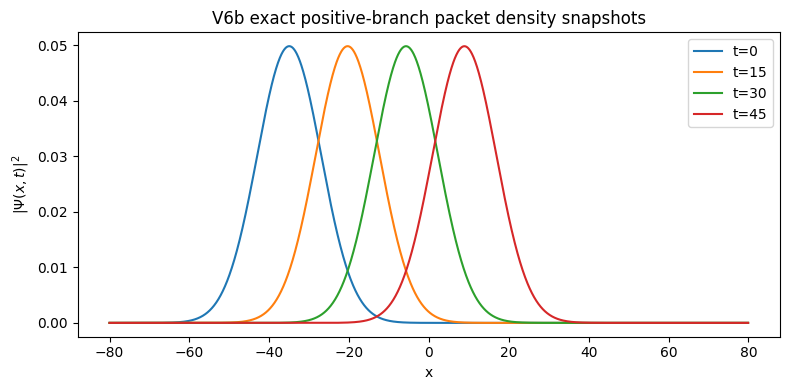

In [ ]:
# ============================================================
# CELL 7 — PACKET DENSITY SNAPSHOTS
# ============================================================
plt.close("all")

plt.figure(figsize=(8,4))
snap_rows = []
for tt in [0, 15, 30, 45]:
    psit = evolve_exact(psi0, tt, chi=1.0)
    rho = np.sum(np.abs(psit)**2, axis=1).real
    plt.plot(x, rho, label=f"t={tt:g}")
    for xi, ri in zip(x, rho):
        snap_rows.append({"t": tt, "x": xi, "rho": ri})

plt.xlabel("x")
plt.ylabel(r"$|\Psi(x,t)|^2$")
plt.title("V6b exact positive-branch packet density snapshots")
plt.legend()
savefig("fig_v6b_packet_density_snapshots.png")
pd.DataFrame(snap_rows).to_csv(OUT/"packet_density_snapshots_v6b.csv", index=False)


 chi  sqrt_chi  norm   norm_error     x_mean  x_width   energy  positive_branch_weight  negative_branch_weight  branch_weight_error
1.00  1.000000   1.0 0.000000e+00  -0.866420 8.001451 1.025195                1.000000            1.006631e-31         1.221245e-15
0.95  0.974679   1.0 0.000000e+00  -1.773836 8.003655 1.000496                0.999992            7.818783e-06         1.332268e-15
0.80  0.894427   1.0 4.440892e-16  -4.663638 8.038606 0.922216                0.999840            1.598751e-04         2.331468e-15
0.50  0.707107   1.0 0.000000e+00 -11.520999 8.262661 0.739497                0.998097            1.902542e-03         4.440892e-16
0.20  0.447214   1.0 1.110223e-16 -21.458516 8.700721 0.485989                0.984955            1.504516e-02         3.774758e-15


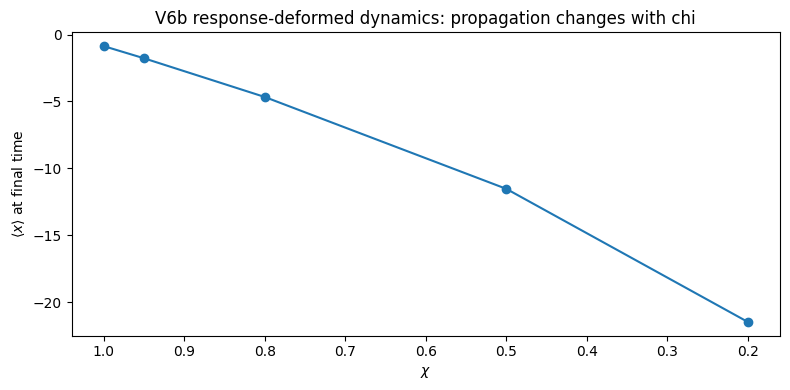

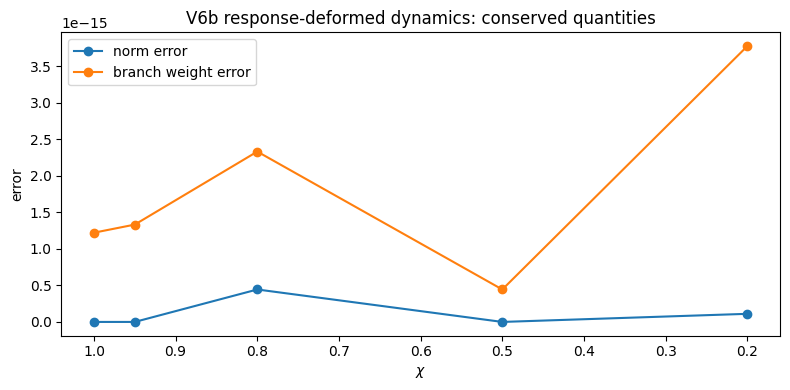

In [ ]:
# ============================================================
# CELL 8 — RESPONSE-DEFORMED DYNAMICS SCAN
# ============================================================
plt.close("all")

chi_values = [1.0, 0.95, 0.8, 0.5, 0.2]
t_final = 35.0
chi_rows = []
for chi in chi_values:
    psit = evolve_exact(psi0, t_final, chi=chi)
    wp, wn = project_branch_weights(psit, chi=chi)
    nrm = norm_psi(psit)
    chi_rows.append({
        "chi": chi,
        "sqrt_chi": np.sqrt(chi),
        "norm": nrm,
        "norm_error": abs(nrm - 1.0),
        "x_mean": expectation_x(psit),
        "x_width": width_x(psit),
        "energy": energy_expectation(psit, chi=chi),
        "positive_branch_weight": wp,
        "negative_branch_weight": wn,
        "branch_weight_error": abs((wp + wn) - 1.0)
    })

chi_df = pd.DataFrame(chi_rows)
chi_df.to_csv(OUT/"response_deformed_dynamics_scan_v6b.csv", index=False)
print(chi_df.to_string(index=False))

plt.figure(figsize=(8,4))
plt.plot(chi_df["chi"], chi_df["x_mean"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel(r"$\chi$")
plt.ylabel(r"$\langle x\rangle$ at final time")
plt.title("V6b response-deformed dynamics: propagation changes with chi")
savefig("fig_v6b_chi_transport_scan.png")

plt.figure(figsize=(8,4))
plt.plot(chi_df["chi"], chi_df["norm_error"], marker="o", label="norm error")
plt.plot(chi_df["chi"], chi_df["branch_weight_error"], marker="o", label="branch weight error")
plt.gca().invert_xaxis()
plt.xlabel(r"$\chi$")
plt.ylabel("error")
plt.title("V6b response-deformed dynamics: conserved quantities")
plt.legend()
savefig("fig_v6b_chi_conservation_errors.png")


  t  E_positive_packet  E_negative_packet  branch_symmetry_abs  norm_pos  norm_neg  overlap_abs
0.0           1.025195          -1.025195         0.000000e+00       1.0       1.0 9.061250e-23
0.5           1.025195          -1.025195         2.220446e-16       1.0       1.0 6.340279e-23
1.0           1.025195          -1.025195         2.220446e-16       1.0       1.0 4.373401e-23
1.5           1.025195          -1.025195         4.440892e-16       1.0       1.0 3.023661e-23
2.0           1.025195          -1.025195         2.220446e-16       1.0       1.0 1.096177e-22
Max energy branch symmetry error: 4.440892098500626e-16
Max pos/neg overlap: 1.7527642934428957e-22


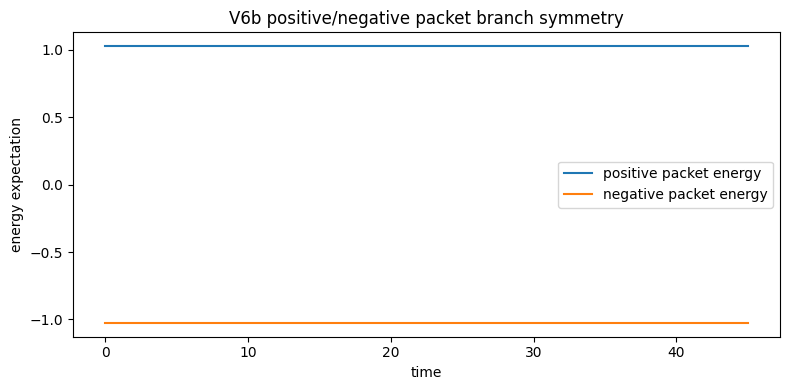

In [ ]:
# ============================================================
# CELL 9 — POSITIVE / NEGATIVE BRANCH SYMMETRY
# ============================================================
plt.close("all")

psi_neg_k = np.zeros((N,4), dtype=complex)
for i, kval in enumerate(k):
    psi_neg_k[i,:] = scalar_k[i] * negative_spinor(kval, chi=1.0)

psi_neg = np.fft.ifft(psi_neg_k, axis=0)
psi_neg = psi_neg / np.sqrt(norm_psi(psi_neg))

pn_rows = []
for tt in times:
    psip = evolve_exact(psi0, tt, chi=1.0)
    psin = evolve_exact(psi_neg, tt, chi=1.0)
    Ep = energy_expectation(psip, chi=1.0)
    En = energy_expectation(psin, chi=1.0)
    pn_rows.append({
        "t": tt,
        "E_positive_packet": Ep,
        "E_negative_packet": En,
        "branch_symmetry_abs": abs(Ep + En),
        "norm_pos": norm_psi(psip),
        "norm_neg": norm_psi(psin),
        "overlap_abs": abs(np.sum(np.sum(np.conj(psip)*psin, axis=1))*dx)
    })

pn_df = pd.DataFrame(pn_rows)
pn_df.to_csv(OUT/"positive_negative_branch_symmetry_v6b.csv", index=False)
print(pn_df.head().to_string(index=False))
print("Max energy branch symmetry error:", pn_df["branch_symmetry_abs"].max())
print("Max pos/neg overlap:", pn_df["overlap_abs"].max())

plt.figure(figsize=(8,4))
plt.plot(pn_df["t"], pn_df["E_positive_packet"], label="positive packet energy")
plt.plot(pn_df["t"], pn_df["E_negative_packet"], label="negative packet energy")
plt.xlabel("time")
plt.ylabel("energy expectation")
plt.title("V6b positive/negative packet branch symmetry")
plt.legend()
savefig("fig_v6b_positive_negative_energy_symmetry.png")


In [ ]:
# ============================================================
# CELL 10 — FINAL V6b VERDICT TABLE
# ============================================================
q_error = abs(float(packet["q_eff"]) + 1.0)
N_plus_error = abs(float(packet["N_plus"]) - 0.0)
N_zero_error = abs(float(packet["N_zero"]) - 1.0)
N_minus_error = abs(float(packet["N_minus"]) - 3.0)

clifford_max_error = float(cliff_df["closure_error_max_abs"].max())
alpha_beta_max_error = float(alpha_df["error"].max())

max_norm_error = float(dyn["norm_error"].max())
max_branch_weight_error = float(dyn["branch_weight_error"].max())
initial_negative_leakage = float(dyn["branch_leakage_negative"].iloc[0])
max_negative_branch_leakage = float(dyn["branch_leakage_negative"].max())
negative_leakage_growth = float(np.max(np.abs(dyn["branch_leakage_negative"] - initial_negative_leakage)))

max_chi_norm_error = float(chi_df["norm_error"].max())
max_chi_branch_weight_error = float(chi_df["branch_weight_error"].max())
max_positive_negative_energy_symmetry_error = float(pn_df["branch_symmetry_abs"].max())
max_positive_negative_overlap = float(pn_df["overlap_abs"].max())

verdict_rows = [
    ("packet remains q=-1 scaffold", q_error, q_error < 5e-3),
    ("packet N_plus near 0", N_plus_error, N_plus_error < 5e-3),
    ("packet N_zero near 1", N_zero_error, N_zero_error < 5e-3),
    ("packet N_minus near 3", N_minus_error, N_minus_error < 5e-3),
    ("Clifford closure inherited", clifford_max_error, clifford_max_error < 1e-12),
    ("alpha/beta closure inherited", alpha_beta_max_error, alpha_beta_max_error < 1e-12),
    ("unitary propagation norm preserved", max_norm_error, max_norm_error < 1e-12),
    ("spectral initial negative leakage negligible", initial_negative_leakage, initial_negative_leakage < 1e-10),
    ("negative branch leakage not dynamically amplified", negative_leakage_growth, negative_leakage_growth < 1e-10),
    ("branch weights conserved", max_branch_weight_error, max_branch_weight_error < 1e-12),
    ("response-deformed norm preserved", max_chi_norm_error, max_chi_norm_error < 1e-12),
    ("response-deformed branch weights conserved", max_chi_branch_weight_error, max_chi_branch_weight_error < 1e-12),
    ("positive/negative energy symmetry", max_positive_negative_energy_symmetry_error, max_positive_negative_energy_symmetry_error < 1e-12),
    ("positive/negative modes remain orthogonal", max_positive_negative_overlap, max_positive_negative_overlap < 1e-12),
]

verdict = pd.DataFrame(verdict_rows, columns=["criterion", "value", "pass"])
verdict.to_csv(OUT/"final_dirac_dynamics_v6b_verdict.csv", index=False)

n_pass = int(verdict["pass"].sum())
n_criteria = int(len(verdict))
if n_pass == n_criteria:
    final_label = "PASS: spectral positive-branch Dirac-like packet propagation with conserved branch structure"
else:
    final_label = "CONDITIONAL/FAIL: spectral positive-branch Dirac-like propagation criteria not all satisfied"

summary = {
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": float(packet["q_eff"]),
    "m_lock_dimensionless": float(m_lock),
    "max_norm_error": max_norm_error,
    "initial_negative_branch_leakage": initial_negative_leakage,
    "max_negative_branch_leakage": max_negative_branch_leakage,
    "negative_leakage_growth": negative_leakage_growth,
    "max_branch_weight_error": max_branch_weight_error,
    "max_chi_norm_error": max_chi_norm_error,
    "max_chi_branch_weight_error": max_chi_branch_weight_error,
    "max_positive_negative_energy_symmetry_error": max_positive_negative_energy_symmetry_error,
    "max_positive_negative_overlap": max_positive_negative_overlap,
}

with open(OUT/"run_summary_v6b.json", "w") as f:
    json.dump(summary, f, indent=2)

print(verdict.to_string(index=False))
print("\nFinal label:", final_label)
print(json.dumps(summary, indent=2))

files = sorted([p.name for p in OUT.iterdir()])
pd.DataFrame({"file": files}).to_csv(OUT/"output_file_manifest_v6b.csv", index=False)
display(pd.DataFrame({"file": files}))


                                        criterion        value  pass
                     packet remains q=-1 scaffold 6.964280e-04  True
                             packet N_plus near 0 9.716379e-04  True
                             packet N_zero near 1 1.460081e-04  True
                            packet N_minus near 3 1.117646e-03  True
                       Clifford closure inherited 0.000000e+00  True
                     alpha/beta closure inherited 0.000000e+00  True
               unitary propagation norm preserved 4.440892e-16  True
     spectral initial negative leakage negligible 1.092348e-31  True
negative branch leakage not dynamically amplified 3.059199e-32  True
                         branch weights conserved 1.332268e-15  True
                 response-deformed norm preserved 4.440892e-16  True
       response-deformed branch weights conserved 3.774758e-15  True
                positive/negative energy symmetry 4.440892e-16  True
        positive/negative modes re

,file
0,alpha_beta_algebra_tests_v6b.csv
1,clifford_closure_tests_v6b.csv
2,dirac_dynamics_history_v6b.csv
3,fig_v6b_branch_preservation.png
4,fig_v6b_chi_conservation_errors.png
5,fig_v6b_chi_transport_scan.png
6,fig_v6b_initial_packet_density.png
7,fig_v6b_norm_preservation.png
8,fig_v6b_packet_density_snapshots.png
9,fig_v6b_packet_transport.png


In [ ]:
# ============================================================
# CELL 11 — ZIP OUTPUTS FOR DOWNLOAD
# ============================================================
zip_path = Path("ecsm_electron_like_dirac_dynamics_v6b_out.zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in sorted(OUT.iterdir()):
        zf.write(p, arcname=p.name)

print("Created:", zip_path.resolve())
print("Files zipped:", len(list(OUT.iterdir())))

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception:
    print("Colab download unavailable here. Download manually:", zip_path)


Created: /content/ecsm_electron_like_dirac_dynamics_v6b_out.zip
Files zipped: 19


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>